In [1]:
# %%
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import cvxpy as cp

from vempc.core.mpc import MPCProblem
from vempc.core import mpc as mpc_utils
from vempc.core.constraints import ConstraintPenalty
from vempc.core.variational import VariationalMPC

from vempc.examples import pendulum
from vempc.solvers import qpMPC
from vempc.solvers import sampling

from vempc.utils import print as print_utils

np.random.seed(0)

/Users/jihoonsuh/Documents/cdc2026/Variational-Encrypted-Model-Predictive-Control/vempc/core/variational.py:91: SyntaxWarning: invalid escape sequence '\c'
  """


## Linearized cart-pole model and discretization
The continuous-time linearized cart-pole dynamics use the state $x = [p,\dot p,\theta,\dot\theta]^\top$ and input
$u$ (cart force):

$\dot p = \dot p$, 

$\ddot{p} = \frac{m g}{M}\,\theta + \frac{1}{M}u$,

$\dot\theta = \dot\theta$,

$\ddot{\theta} = -\frac{(M+m)g}{lM}\,\theta - \frac{1}{lM}u$.

The code discretizes this linear system with step size $dt$ to obtain the discrete matrices $(A,B)$ used in
MPC: $x_{k+1} = A x_k + B u_k$.

This block also sets the LQ weights in the finite-horizon cost
$ J_0(x_0,U_0) = x_N^\top Q_f x_N + \sum_{k=0}^{N-1}(x_k^\top Q x_k + u_k^\top R u_k) $
and the polyhedral bounds
$ X := \{x: G_x x \le h_x\}$, $U := \{u: G_u u \le h_u\}$ with
$G_x=[I;-I]$ and $G_u=[I;-I]$.



In [10]:
# system parameters
M, m, l, g = 1.0, 0.1, 0.5, 9.81
dt = 0.01

Ac, Bc = pendulum.linearized_cartpole_continuous(M=M, m=m, l=l, g=g)
A, B = pendulum.discretize(Ac, Bc, dt)

n, m_in = A.shape[0], B.shape[1]

# Horizon and simulation length
N = 20           # MPC horizon
T_steps = 2000    # simulation steps

# Weights (tune these as needed)
Q  = np.diag([10.0, 1.0, 200.0, 5.0])   # [pos, vel, theta, omega]
R  = np.diag([0.2])
Qf = 5.0 * Q

# Constraints: |x_i| <= x_max_i, |u| <= u_max
x_max     = 2.0
v_max     = 1.0
theta_max = 0.35   # rad (~20 deg)
omega_max = 3.0

u_max = 1.0

x_bound = np.array([x_max, v_max, theta_max, omega_max])

# Polyhedral bounds Gx x <= hx with Gx = [I; -I]
Gx = np.vstack([np.eye(n), -np.eye(n)])
hx = np.hstack([x_bound, x_bound])

Gu = np.vstack([np.eye(m_in), -np.eye(m_in)])
hu = np.hstack([np.array([u_max]), np.array([u_max])])


# Uncomment to print
# print_utils.print_setup(M, m, l, g, dt, Ac, Bc, A, B, N, T_steps, Q, R, Qf,
                #   x_max, v_max, theta_max, omega_max, u_max,
                #   x_bound, Gx, hx, Gu, hu)


## Compact representation of MPC
Using the compact MPC representation (paper Sec. IV-A), the state
trajectory satisfies

$ X = \Lambda x_0 + \Psi U $. 

The quadratic cost is

$ J_0(x_0,U) = x_0^\top P x_0 + x_0^\top S U + \tfrac12 U^\top H U $,

with

$ P = Q + \Lambda^\top \bar Q \Lambda $,

$ S = 2\Lambda^\top \bar Q \Psi $,

$ H = 2(\bar R + \Psi^\top \bar Q \Psi) $.

State/input constraints are condensed into
$ G U \le h(x_0) $, where

$ G = \begin{bmatrix}\bar G_x\Psi \\ \bar G_u\end{bmatrix} $

and

$ h(x_0) = \begin{bmatrix}\bar h_x - \bar G_x\Lambda x_0 \\ \bar h_u\end{bmatrix} $.

The residual is $ g(U;x_0) := G U - h(x_0) $, and the feasible set is
$ F(x_0) := \{U : g(U;x_0) \le 0\} $ with desirability
$ r(U;x_0) := \mathbf{1}_{F(x_0)}(U) $.



In [11]:
# Build condensed MPC using core implementation
mpc = MPCProblem(A, B, Q, R, Qf, N)

P, S, H = mpc.P, mpc.S, mpc.H
Lambda, Psi = mpc.Lambda, mpc.Psi

G, h_of_x0 = mpc.build_constraint_matrices(Gx, hx, Gu, hu)
penalty = ConstraintPenalty(G, h_of_x0)

Nm = mpc.Nm
p_total = G.shape[0]

# Uncomment to print
# print_utils.print_condensed_mpc(P, S, H, Lambda, Psi, G)


## QP-MPC using indicator function
Uses the hard indicator function from the paper to express the
constrained QP as an unconstrained objective

$\min_{U\in\mathbb{R}^{Nm}} \; \tfrac12 U^\top H U + (S^\top x_0)^\top U + \mathbf{1}_{F(x_0)}(U)$,

where $\mathbf{1}_{F(x_0)}(U)=0$ if $GU \le h(x_0)$ and $+\infty$ otherwise.
The constant term $x_0^\top P x_0$ is omitted since it does not affect the
optimizer. The solver returns the optimal sequence $U^*$ and applies the
first input $u_0$.




In [12]:
# %%
# Standard QP-MPC (explicit constraints)
prob_qp_std, U_var_std, q_par_std, h_par_std = qpMPC.make_standard_qp_solver(H, G)

# Chebyshev approximation settings for the indicator surrogate
cheb_order = 3
cheb_bound = 10.0
eta_indicator = 2.0
indicator_maxiter = 5000
indicator_ftol = 1e-8
indicator_gtol = 1e-4
cheb_weight_mode = "exp"  # or "exp"

indicator_solver = qpMPC.make_indicator_qp_solver(
    H, G, cheb_order=cheb_order, cheb_bound=cheb_bound, eta=eta_indicator
)

def solve_standard_mpc(x0, warm_start_U=None, verbose=False):
    return qpMPC.solve_standard_mpc(
        x0,
        S=S,
        h_of_x0=h_of_x0,
        m_in=m_in,
        prob=prob_qp_std,
        U_var=U_var_std,
        q_par=q_par_std,
        h_par=h_par_std,
        warm_start_U=warm_start_U,
        verbose=verbose,
    )

def solve_indicator_mpc(x0, warm_start_U=None, verbose=False):
    return qpMPC.solve_indicator_mpc(
        x0,
        S=S,
        h_of_x0=h_of_x0,
        m_in=m_in,
        solver=indicator_solver,
        warm_start_U=warm_start_U,
        verbose=verbose,
        maxiter=indicator_maxiter,
        ftol=indicator_ftol,
        gtol=indicator_gtol,
    )






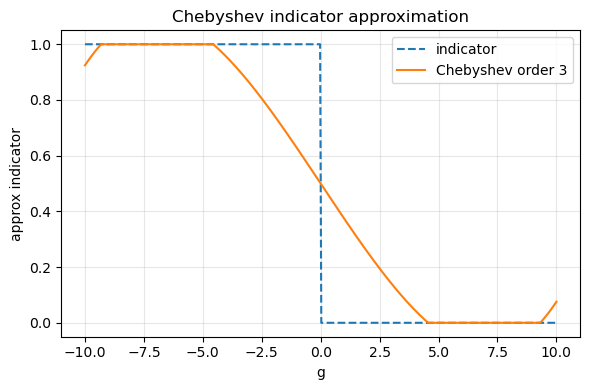

In [13]:
# %%
# Plot Chebyshev indicator approximation
z = np.linspace(-cheb_bound, cheb_bound, 400)
p = qpMPC.eval_indicator_poly(z, indicator_solver['coeffs'], cheb_bound, clip=True)
plt.figure(figsize=(6, 4))
plt.plot(z, (z <= 0).astype(float), '--', label='indicator')
plt.plot(z, p, label=f'Chebyshev order {cheb_order}')
plt.xlabel('g')
plt.ylabel('approx indicator')
plt.title('Chebyshev indicator approximation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Variational MPC sampling (tilted Gaussian, hard feasibility only)
Following the paper, the reference distribution is

$\kappa_0 = \mathcal{N}(0,\Sigma_0)$. 

Exponential tilting yields

$\tilde\kappa(\cdot\mid x_0) = \mathcal{N}(m_U(x_0), \Sigma_U)$ 

with

$ \Sigma_U = (\Sigma_0^{-1} + \tfrac{1}{\lambda} H)^{-1} $,

$ m_U(x_0) = -\tfrac{1}{\lambda} \Sigma_U S^\top x_0 $.

Sampling uses

 $ U^{(i)} = m_U(x_0) + L_U\,\xi^{(i)} $, $\xi^{(i)}\sim\mathcal{N}(0,I)$,

with $\Sigma_U = L_U L_U^\top$. The feasibility indicator is

$ r(U;x_0) = \mathbf{1}_{F(x_0)}(U) $, where $F(x_0)=\{U: GU \le h(x_0)\}$.

The quadratic cost is absorbed into $\tilde\kappa$ through exponential tilting.
Therefore, 

$ w_i = r(U^{(i)};x_0) \in \{0,1\} $.

and the Monte Carlo estimator (paper Eq. (29)-(30)) is

$ \hat U_K(x_0) = \frac{\sum_i U^{(i)} w_i}{\sum_i w_i} $.

The controller applies the first element of $\hat U_K$.



## Closed-loop simulation with three controllers
This block runs a receding-horizon simulation for $T$ steps. At each step:

1. Solve for $U$ (QP-MPC, unconstrained, or variational sampling).
2. Apply the first input $u_0$.
3. Propagate the dynamics $x_{k+1} = A x_k + B u_k$.

The QP controller is warm-started with the previous $U$ sequence. The results
are stored in dictionaries for plotting.



In [14]:
# %%
# initial condition (small deviation from upright)
x0 = np.array([0.3, 0.0, 0.20, 0.0])  # theta=0.20 rad

# Controller 1: Standard MPC (QP)
def ctrl_standard(x, U_warm):
    u, Useq = solve_standard_mpc(x, warm_start_U=U_warm, verbose=False)
    return u, Useq

# Controller 2: Indicator-form MPC (QP)
def ctrl_indicator(x, U_warm):
    u, Useq = solve_indicator_mpc(x, warm_start_U=U_warm, verbose=False)
    return u, Useq

# run baseline MPC controllers
xs_std, us_std, info_std, t_std = mpc_utils.simulate(
    "Standard MPC", x0, ctrl_standard, A=A, B=B, T_steps=T_steps
)
xs_ind, us_ind, info_ind, t_ind = mpc_utils.simulate(
    "Indicator QP-MPC", x0, ctrl_indicator, A=A, B=B, T_steps=T_steps
)

baseline_results = {
    "Standard MPC": {
        "xs": xs_std,
        "us": us_std,
        "runtime": t_std,
        "cost": mpc_utils.trajectory_cost(xs_std, us_std, Q=Q, R=R, Qf=Qf),
        "viol": mpc_utils.max_constraint_violation(xs_std, us_std, Gx=Gx, hx=hx, Gu=Gu, hu=hu),
    },
    "Indicator QP-MPC": {
        "xs": xs_ind,
        "us": us_ind,
        "runtime": t_ind,
        "cost": mpc_utils.trajectory_cost(xs_ind, us_ind, Q=Q, R=R, Qf=Qf),
        "viol": mpc_utils.max_constraint_violation(xs_ind, us_ind, Gx=Gx, hx=hx, Gu=Gu, hu=hu),
    },
}



In [15]:

# Variational sampling MPC
sigma0 = 5.0 # nominal
Sigma0 = (sigma0**2) * np.eye(Nm)
K_samples = 2000 # number of samples
lambda_values = [0.5, 1.0, 2.0, 5.0]
lambda_plot = 2.0


variational_runs = {}
for lam in lambda_values:
    variational = VariationalMPC(mpc_problem=mpc, penalty=penalty, lambda_param=lam, Sigma_0=Sigma0)

    def ctrl_variational(x, _, _variational=variational):
        u, Useq, info = sampling.sample_variational_control(
            x, variational=_variational, penalty=penalty, K=K_samples,
            cheb_coeffs=indicator_solver["coeffs"],
            cheb_bound=cheb_bound,
            cheb_clip=True,
            cheb_weight_mode=cheb_weight_mode,
            cheb_eta=eta_indicator,
        )
        return u, Useq, info

    xs, us, info, elapsed = mpc_utils.simulate(
        f"Variational (lam={lam})", x0, ctrl_variational, A=A, B=B, T_steps=T_steps
    )
    variational_runs[lam] = {
        "xs": xs,
        "us": us,
        "info": info,
        "runtime": elapsed,
        "cost": mpc_utils.trajectory_cost(xs, us, Q=Q, R=R, Qf=Qf),
        "viol": mpc_utils.max_constraint_violation(xs, us, Gx=Gx, hx=hx, Gu=Gu, hu=hu),
        "accept": mpc_utils.avg_acceptance(info),
    }

if lambda_plot not in variational_runs:
    lambda_plot = lambda_values[0]


In [16]:
# Print runtime / cost summary
print("\n=== Runtime / Cost Summary ===")
for name, res in baseline_results.items():
    vx, vu = res["viol"]
    print(f"{name:20s} | runtime={res['runtime']:.3f}s | cost={res['cost']:.3f} | max viol x={vx:.3e}, u={vu:.3e}")

print("\n--- Variational MPC (hard) across lambda ---")
for lam in lambda_values:
    res = variational_runs[lam]
    vx, vu = res["viol"]
    print(f"lam={lam:<4} | runtime={res['runtime']:.3f}s | cost={res['cost']:.3f} | max viol x={vx:.3e}, u={vu:.3e} | accept={res['accept']:.3f}")

# Plot selection dictionaries
xs_dict = {
    "Standard MPC": baseline_results["Standard MPC"]["xs"],
    "Indicator QP-MPC": baseline_results["Indicator QP-MPC"]["xs"],
    f"Variational (lam={lambda_plot})": variational_runs[lambda_plot]["xs"],
}

us_dict = {
    "Standard MPC": baseline_results["Standard MPC"]["us"],
    "Indicator QP-MPC": baseline_results["Indicator QP-MPC"]["us"],
    f"Variational (lam={lambda_plot})": variational_runs[lambda_plot]["us"],
}



=== Runtime / Cost Summary ===
Standard MPC         | runtime=1.113s | cost=1627.957 | max viol x=0.000e+00, u=1.945e-05
Indicator QP-MPC     | runtime=2.196s | cost=3023.711 | max viol x=0.000e+00, u=1.477e+00

--- Variational MPC (hard) across lambda ---
lam=0.5  | runtime=11.115s | cost=3032.176 | max viol x=0.000e+00, u=1.485e+00 | accept=0.000
lam=1.0  | runtime=9.991s | cost=3031.420 | max viol x=0.000e+00, u=1.389e+00 | accept=0.000
lam=2.0  | runtime=10.138s | cost=3028.517 | max viol x=0.000e+00, u=1.216e+00 | accept=0.000
lam=5.0  | runtime=10.230s | cost=3011.583 | max viol x=0.000e+00, u=8.178e-01 | accept=0.000


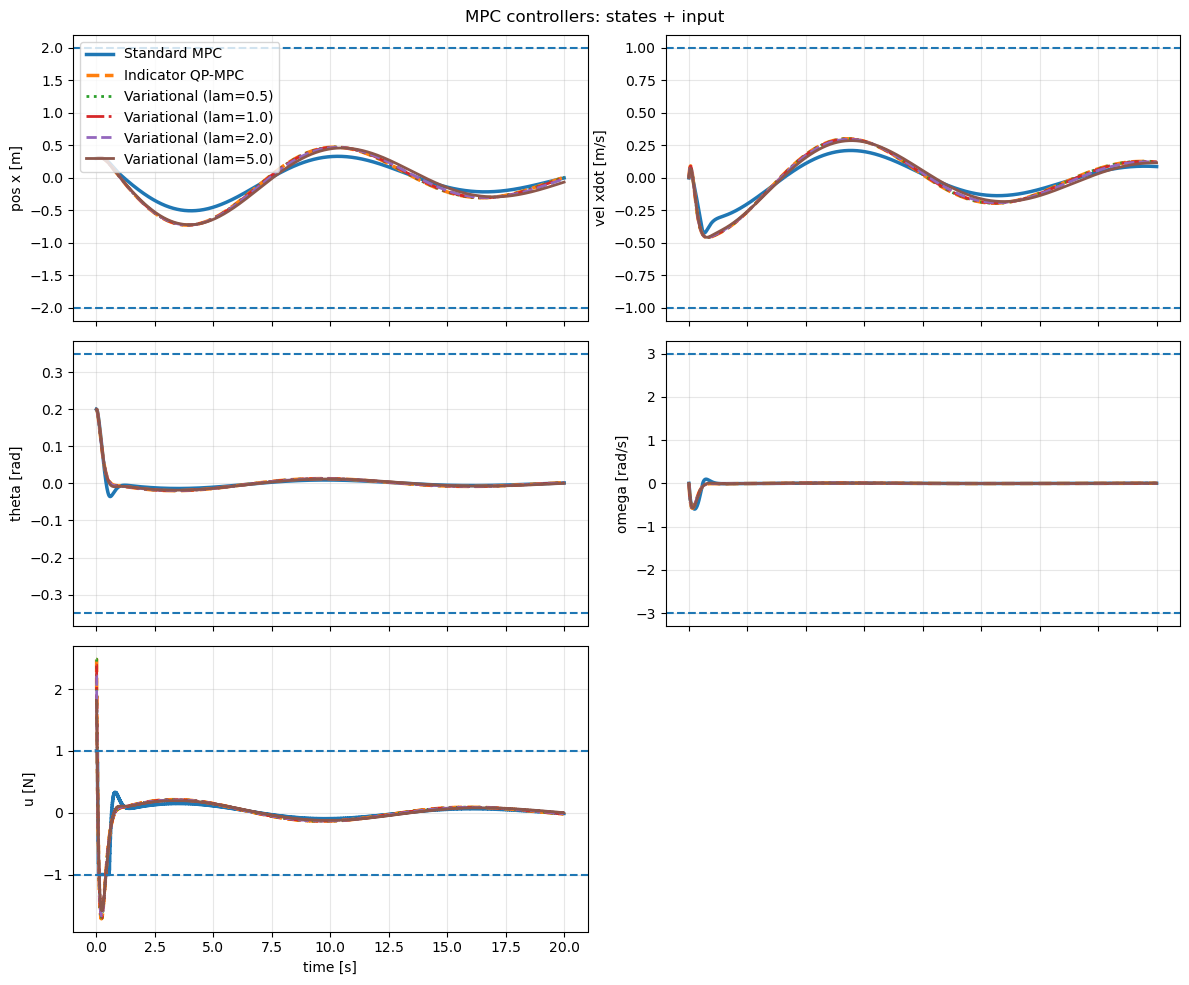

In [17]:
# %%
t  = np.arange(T_steps + 1) * dt
tu = np.arange(T_steps) * dt

def plot_compare(xs_dict, us_dict, title_prefix="Comparison", style_map=None):
    """
    xs_dict: {"label": xs_array} where xs_array shape = (T_steps+1, n)
    us_dict: {"label": us_array} where us_array shape = (T_steps, m)

    style_map: {"label": dict_of_matplotlib_style_kwargs}
               e.g., {"QP": {"linestyle":"-"}, "Uncon": {"linestyle":"--"}}
    """
    labels = list(xs_dict.keys())

    # Default styles if not provided
    if style_map is None:
        ls_list = ["-", "--", ":", "-."]  # will cycle
        style_map = {lab: {"linestyle": ls_list[i % len(ls_list)], "linewidth": 2.0}
                     for i, lab in enumerate(labels)}

    fig, ax = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
    ax = ax.ravel()

    # --- x ---
    for lab in labels:
        ax[0].plot(t, xs_dict[lab][:, 0], label=lab, **style_map.get(lab, {}))
    ax[0].axhline(+x_max, linestyle="--")
    ax[0].axhline(-x_max, linestyle="--")
    ax[0].set_ylabel("pos x [m]")
    ax[0].grid(True, alpha=0.3)

    # --- xdot ---
    for lab in labels:
        ax[1].plot(t, xs_dict[lab][:, 1], label=lab, **style_map.get(lab, {}))
    ax[1].axhline(+v_max, linestyle="--")
    ax[1].axhline(-v_max, linestyle="--")
    ax[1].set_ylabel("vel xdot [m/s]")
    ax[1].grid(True, alpha=0.3)

    # --- theta ---
    for lab in labels:
        ax[2].plot(t, xs_dict[lab][:, 2], label=lab, **style_map.get(lab, {}))
    ax[2].axhline(+theta_max, linestyle="--")
    ax[2].axhline(-theta_max, linestyle="--")
    ax[2].set_ylabel("theta [rad]")
    ax[2].grid(True, alpha=0.3)

    # --- omega ---
    for lab in labels:
        ax[3].plot(t, xs_dict[lab][:, 3], label=lab, **style_map.get(lab, {}))
    ax[3].axhline(+omega_max, linestyle="--")
    ax[3].axhline(-omega_max, linestyle="--")
    ax[3].set_ylabel("omega [rad/s]")
    ax[3].grid(True, alpha=0.3)

    # --- input u ---
    for lab in labels:
        ax[4].step(tu, us_dict[lab][:, 0], where="post", label=lab, **style_map.get(lab, {}))
    ax[4].axhline(+u_max, linestyle="--")
    ax[4].axhline(-u_max, linestyle="--")
    ax[4].set_ylabel("u [N]")
    ax[4].set_xlabel("time [s]")
    ax[4].grid(True, alpha=0.3)

    # Empty panel for legend / spacing
    ax[5].axis("off")
    ax[0].legend(loc="best")

    fig.suptitle(f"{title_prefix}: states + input")
    plt.tight_layout()
    plt.show()


# Build plot dictionaries with all lambda runs
xs_dict = {
    "Standard MPC": baseline_results["Standard MPC"]["xs"],
    "Indicator QP-MPC": baseline_results["Indicator QP-MPC"]["xs"],
}

us_dict = {
    "Standard MPC": baseline_results["Standard MPC"]["us"],
    "Indicator QP-MPC": baseline_results["Indicator QP-MPC"]["us"],
}

for lam in lambda_values:
    xs_dict[f"Variational (lam={lam})"] = variational_runs[lam]["xs"]
    us_dict[f"Variational (lam={lam})"] = variational_runs[lam]["us"]

# Explicit style choices per controller (easy to read when overlapping)
style_map = {
    "Standard MPC":       {"linestyle": "-",  "linewidth": 2.5},
    "Indicator QP-MPC":    {"linestyle": "--", "linewidth": 2.5},
}

# Add a distinct style per lambda
linestyles = [":", "-.", "--", "-"]
for i, lam in enumerate(lambda_values):
    style_map[f"Variational (lam={lam})"] = {
        "linestyle": linestyles[i % len(linestyles)],
        "linewidth": 2.0,
    }

plot_compare(xs_dict, us_dict, title_prefix="MPC controllers", style_map=style_map)

